# From Pauli matrices to any SU(N): gauge representations with `feynlag`

*A gentle tour for someone new to particle physics — you need only linear algebra
and a little quantum mechanics.*

Quarks come in **three colours**. The weak force acts on **doublets**. Grand unified
theories pack a whole matter generation into a **$\bar 5$ and a $10$** of SU(5). Every
one of these statements is about a **representation of a Lie group** — the mathematical
language of gauge symmetry.

This notebook builds that language from the ground up, and shows how `feynlag` now
constructs the generators of **any** SU($N$) representation *dynamically* — with no
hard-coded matrices beyond the familiar Pauli and Gell-Mann ones.

**Roadmap**

1. Symmetries and generators
2. The Lie algebra
3. Representations: one symmetry, many sizes
4. Labelling representations: dimension and Dynkin labels
5. A peek inside: highest weights and ladder operators
6. Conjugate representations: matter vs antimatter
7. Anomalies: a consistency test the representations must pass
8. Putting it to work: a model in a brand-new representation
9. Recap

In [ ]:
import sympy as sp
sp.init_printing()   # pretty-print matrices as LaTeX

from feynlag import (SU2, SU3, SUN, Scalar, WeylFermion, Model,
                     ExternalParameter, Lagrangian, Dmu,
                     structure_constants, check_anomaly_free)
from feynlag.groups import sun

## 1. Symmetries and generators

A **symmetry** in particle physics acts on a *multiplet* of fields — a column of $n$
objects that the transformation mixes among themselves. Mixing $n$ things linearly is
just multiplication by an $n\times n$ matrix $U$.

For a **continuous** symmetry we can turn the transformation on gently. Very close to
"doing nothing" ($U = \mathbb{1}$), any such transformation looks like

$$U(\alpha) \;\approx\; \mathbb{1} + i\,\alpha\, T + \dots$$

The matrix $T$ that appears at first order is a **generator**: it *generates* the whole
family of transformations. A group with several independent "directions" of
transformation has several generators $T^a$ ($a = 1, 2, \dots$).

The smallest non-trivial example is **SU(2)**, acting on a 2-component doublet (think of
the weak isospin of $(\nu_e, e)_L$). Its three generators in this 2-dimensional
(*fundamental*) representation are the **Pauli matrices divided by two**:

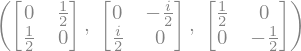

In [ ]:
SU2L = SU2('SU2L')
T = SU2L.generators(2)      # '2' = the 2-dimensional (fundamental) rep
T[0], T[1], T[2]

Two facts you can read straight off these matrices, both *required* of any generator of
a special-unitary group:

- they are **Hermitian** ($T = T^\dagger$) — so that $U = e^{i\alpha T}$ is unitary
  (probability-preserving),
- they are **traceless** — the "S" (for *special*) in SU($N$).

In [ ]:
all(Ta == Ta.conjugate().T for Ta in T), [sp.trace(Ta) for Ta in T]

(True, [0, 0, 0])

## 2. The Lie algebra: how generators multiply

Generators do not commute — that is what makes the group *non-abelian* and the physics
rich. The way they fail to commute is the single most important piece of data about the
group:

$$[T^a, T^b] \;=\; T^aT^b - T^bT^a \;=\; i\, f^{abc}\, T^c .$$

The numbers $f^{abc}$ are the **structure constants**. They *are* the group, in the
sense that everything else can be reconstructed from them.

Let us verify the relation for SU(2). Taking $a=1, b=2$ (Python indices `0, 1`), the
commutator should come out equal to $i\,T^3$:

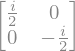

In [ ]:
comm = T[0] * T[1] - T[1] * T[0]
comm

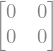

In [ ]:
sp.simplify(comm - sp.I * T[2])     # zero matrix  =>  f^{123} = +1

For SU(2) the structure constants are just the Levi-Civita symbol,
$f^{abc} = \varepsilon^{abc}$. `feynlag` can hand them to us as a dictionary of the
non-zero entries:

In [ ]:
structure_constants(SU2L)

One more standard convention: the generators are **normalised** so that

$$\mathrm{Tr}(T^a T^b) = \tfrac{1}{2}\,\delta^{ab}.$$

The matrix of all traces is therefore $\tfrac12$ times the identity:

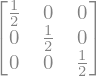

In [ ]:
sp.Matrix(3, 3, lambda a, b: sp.trace(T[a] * T[b]))

## 3. Representations: one symmetry, many sizes

Here is the key idea. The *same* abstract symmetry can act on multiplets of **different
sizes** — on a doublet, a triplet, an octet, .... Each such realisation is a
**representation**: a set of matrices $T^a$ (of some common size) obeying the *same* Lie
algebra, i.e. with the *same* structure constants $f^{abc}$.

Three representations exist for every group and deserve names:

- the **singlet** — a 1-dimensional field that does not transform at all ($T^a = 0$); it
  is *neutral* under the force.
- the **fundamental** — the smallest faithful one ($N\times N$ for SU($N$)); quarks live
  in the fundamental **3** of colour SU(3).
- the **adjoint** — same dimension as the number of generators; it is built directly out
  of the structure constants, $(T^a)_{bc} = -i f^{abc}$. The force-carrying gauge bosons
  (gluons!) live here.

Let us look at colour **SU(3)**. Its fundamental has eight $3\times 3$ generators — the
**Gell-Mann matrices over two**:

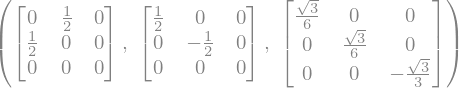

In [ ]:
SU3c = SU3('SU3c')
lam = SU3c.generators(3)    # 8 generators, each 3x3
lam[0], lam[2], lam[7]

The adjoint (the **8**, home of the gluons) is eight $8\times 8$ matrices; the singlet is
trivial. Same group, three different sizes:

In [ ]:
print('fundamental 3:', lam[0].shape,
      '  adjoint 8:', SU3c.generators(8)[0].shape,
      '  singlet 1:', SU3c.generators(1)[0].shape)

fundamental 3: (3, 3)   adjoint 8: (8, 8)   singlet 1: (1, 1)


And — this is the whole point of the word *representation* — the octet obeys **the same
algebra** as the triplet, with the very same $f^{abc}$:

In [ ]:
f3 = structure_constants(SU3c)
adj = SU3c.generators(8)
comm = adj[0] * adj[1] - adj[1] * adj[0]
rhs = sum((sp.I * f3.get((0, 1, c), 0) * adj[c] for c in range(8)), sp.zeros(8, 8))
sp.simplify(comm - rhs) == sp.zeros(8, 8)

True

## 4. Labelling representations: dimension and Dynkin labels

So far we used **dimension labels**: `1` (singlet), `3` (fundamental of SU(3)), `8`
(adjoint). That is convenient but incomplete — for a general group there can be *several*
representations of the same dimension, so dimension alone is ambiguous.

`feynlag` therefore lets you build **any** SU($N$) with `SUN(N, name)`, and label a
representation in three ways:

- by its **integer dimension** (`1`, `N`, `N`$^2-1$, or any dimension that is
  unambiguous),
- by an explicit **Dynkin label** — a tuple $(a_1, \dots, a_{N-1})$ of non-negative
  integers that names *exactly one* representation,
- by a **conjugate** label (Section 6).

Here is SU(4), with its singlet, fundamental (**4**) and adjoint (**15**):

In [ ]:
SU4 = SUN(4, 'SU4')
[SU4.rep_dim(1), SU4.rep_dim(4), SU4.rep_dim(15)]

The dimension of *any* representation follows from its Dynkin labels through the **Weyl
dimension formula** (a piece of pure combinatorics — no matrices are built to evaluate
it). Here is a small catalogue of SU(3) representations, each named by its Dynkin label:

In [ ]:
for dyn in [(0, 0), (1, 0), (0, 1), (1, 1), (2, 0), (0, 2), (3, 0)]:
    print(f'Dynkin {dyn}  ->  dimension {sun.weyl_dim(3, dyn)}')

Dynkin (0, 0)  ->  dimension 1
Dynkin (1, 0)  ->  dimension 3
Dynkin (0, 1)  ->  dimension 3
Dynkin (1, 1)  ->  dimension 8
Dynkin (2, 0)  ->  dimension 6
Dynkin (0, 2)  ->  dimension 6
Dynkin (3, 0)  ->  dimension 10


Notice that $(1,0)$ and $(0,1)$ are *both* 3-dimensional: they are the quark and
antiquark representations (Section 6). Notice too that dimension $15$ would be ambiguous.
The resolver `resolve_rep` translates a friendly label into a canonical Dynkin tuple
(plus a flag for whether it is conjugated), and it *refuses to guess* when a dimension is
ambiguous:

In [ ]:
sun.resolve_rep(3, 6), sun.resolve_rep(3, '3bar'), sun.resolve_rep(3, (2, 0))

(((2, 0), False), ((1, 0), True), ((2, 0), False))

In [ ]:
try:
    sun.resolve_rep(3, 15)          # dimension 15 is ambiguous in SU(3)
except ValueError as e:
    print('ValueError:', e)

ValueError: SU(3) dimension 15 is ambiguous ((4, 0), (2, 1)); pass an explicit Dynkin tuple


## 5. A peek inside: highest weights and ladder operators

Where do the matrices for, say, the **6** of SU(3) actually *come from*? The construction
is a direct generalisation of something you already know from quantum mechanics:
**building an angular-momentum multiplet with raising and lowering operators**.

Recall the spin-$j$ story. You start from the **highest-weight** state $|j, j\rangle$ and
apply the lowering operator $J_-$ again and again to sweep out the whole multiplet
$|j, j-1\rangle, |j, j-2\rangle, \dots$. The matrix elements are square roots,

$$J_\pm\,|j, m\rangle = \sqrt{(j \mp m)(j \pm m + 1)}\;|j, m\pm 1\rangle .$$

A general SU($N$) irrep is built exactly this way — pick the highest-weight state, then
lower with the group's ladder operators to fill in every state. (The systematic
bookkeeping is the *Gelfand–Tsetlin* construction; `feynlag` does it for you.) The
fingerprint is the same: the ladder matrix elements come out as **square roots of
rationals**.

Watch it appear. Here is the **6** of SU(3) — six $6\times 6$ generators — and its
raising combination $T^1 + iT^2$:

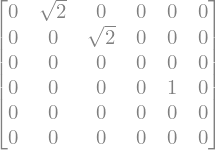

In [ ]:
six = sun.su_n_generators(3, (2, 0))   # the 6 of SU(3)
raiser = six[0] + sp.I * six[1]
raiser

There are the tell-tale $\sqrt{2}$'s — the very same ladder structure as $J_+$ in the
spin story, now inside a colour representation.

And the pay-off that makes this a genuine *representation*: these six $6\times 6$
matrices, produced purely by the ladder algorithm, satisfy the **same** structure
constants $f^{abc}$ as the $3\times 3$ fundamental. The library shares one common basis
across every representation precisely so this holds automatically:

In [ ]:
def closes(T, f, dim, n=8):
    return all(
        sp.expand((T[a] * T[b] - T[b] * T[a])
                  - sum((sp.I * f.get((a, b, c), 0) * T[c] for c in range(n)),
                        sp.zeros(dim, dim))) == sp.zeros(dim, dim)
        for a in range(n) for b in range(n))

closes(six, f3, 6)     # the 6 obeys the SAME algebra as the 3

True

Finally, a representation carries an intrinsic number, its **quadratic Casimir**
$C_2 = \sum_a T^aT^a$, which is a multiple of the identity (a fact guaranteed by *Schur's
lemma*). For the **6** of SU(3) it is $10/3$:

In [ ]:
C2 = sum((Ta * Ta for Ta in six), sp.zeros(6, 6))
C2[0, 0], C2 == C2[0, 0] * sp.eye(6)

(10/3, True)

## 6. Conjugate representations: matter vs antimatter

For every representation $R$ there is a **conjugate** representation $\bar R$ —
physically, the one the *antiparticles* live in. If quarks are a **3** of colour,
antiquarks are a $\bar{\mathbf 3}$. The generators of the conjugate are

$$\bar T^{\,a} = -\,(T^a)^{*} .$$

In `feynlag` you ask for a conjugate with a string like `'3bar'`, a negative integer, or
the reversed Dynkin tuple. It really is $-(T^a)^*$:

In [ ]:
three = SU3c.generators(3)
threebar = SU3c.generators('3bar')
all(tb == -t.conjugate() for tb, t in zip(threebar, three))

True

We already saw that the Dynkin label of $\bar{\mathbf 3}$ is $(0,1)$, the reverse of the
fundamental's $(1,0)$:

In [ ]:
sun.resolve_rep(3, '3bar')      # -> ((1, 0), True):  the conjugate of (1, 0)

((1, 0), True)

This is exactly why a quark ($\mathbf 3$) and an antiquark ($\bar{\mathbf 3}$) can bind
into a colour-neutral **singlet** — a meson. Combining a representation with its conjugate
always contains the singlet. (For a *real* representation, such as the SU(3) octet,
$R = \bar R$ and the distinction disappears.)

## 7. Anomalies: a consistency test the representations must pass

Not every collection of representations gives a healthy theory. In a **chiral** gauge
theory (one where left- and right-handed fermions transform differently — like the real
world), a quantum effect called the **triangle anomaly** can spoil the gauge symmetry
unless it **cancels** between the particles. This is a genuine constraint that *rules
models in or out*.

Each representation contributes an **anomaly coefficient** $A(R)$, fixed by a symmetric
trace of three generators and normalised to $A(\text{fundamental}) = 1$. Here it is,
written out transparently:

In [ ]:
def anomaly_index(group, rep):
    T = group.generators(rep)
    TF = group.generators(group.N)           # the fundamental, for normalisation
    n = len(TF)
    for a in range(n):
        for b in range(a, n):
            for c in range(b, n):
                tF = sp.nsimplify(sp.expand(
                    sp.trace(TF[a] * (TF[b] * TF[c] + TF[c] * TF[b]))))
                if tF != 0:
                    num = sp.nsimplify(sp.expand(
                        sp.trace(T[a] * (T[b] * T[c] + T[c] * T[b]))))
                    return sp.simplify(num / tF)
    return sp.S.Zero

{'A(3)': anomaly_index(SU3c, 3), 'A(3bar)': anomaly_index(SU3c, '3bar'),
 'A(6)': anomaly_index(SU3c, 6), 'A(8)': anomaly_index(SU3c, 8)}

{'A(3)': 1, 'A(3bar)': -1, 'A(6)': 7, 'A(8)': 0}

A real ($R=\bar R$) representation like the **8** has $A = 0$; a conjugate flips the sign,
$A(\bar R) = -A(R)$.

Now the famous example. In the **SU(5)** grand unified theory, one whole generation of
matter fits into a left-handed $\bar{\mathbf 5}$ **plus** a $\mathbf{10}$. Individually
each is anomalous — but their anomalies **cancel**,
$A(\bar{\mathbf 5}) + A(\mathbf{10}) = -1 + 1 = 0$. That near-miraculous cancellation is
one of the reasons SU(5) was taken seriously as a unifying group:

In [ ]:
SU5 = SUN(5, 'SU5')
anomaly_index(SU5, '5bar'), anomaly_index(SU5, (0, 1, 0, 0))   # 10 = (0,1,0,0)

And we can let the library confirm the cancellation on a real model — two left-handed
fermion multiplets making up one generation, checked by `check_anomaly_free`. Note the
fields are declared directly in the higher representations, including the $\mathbf{10}$ by
its Dynkin tuple:

In [ ]:
five_bar = WeylFermion('fbar', reps={SU5: '5bar'}, chirality='L',
                       nflavors=1, component_names=[f'fb_{i}' for i in range(5)])
ten = WeylFermion('ften', reps={SU5: (0, 1, 0, 0)}, chirality='L',
                  nflavors=1, component_names=[f'ft_{i}' for i in range(10)])
generation = Model('SU5generation', gauge_groups=[SU5], fields=[five_bar, ten])
check_anomaly_free(generation).ok

True

## 8. Putting it to work: a model in a brand-new representation

None of this would matter if you could not *use* the new representations to build a
Lagrangian. You can. Let us give a scalar field the **fundamental of SU(4)** — a group
`feynlag` never had built in — and form its **covariant derivative**
$D_\mu S = \partial_\mu S - i g\,A^a_\mu T^a S$. The covariant derivative automatically
uses the SU(4) fundamental generators we met above:

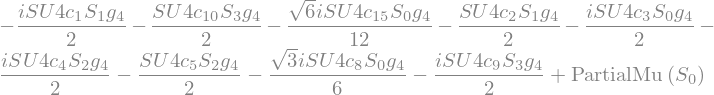

In [ ]:
g4 = ExternalParameter('g4', 0.9, positive=True)
SU4c = SUN(4, 'SU4c', coupling=g4)
S = Scalar('S', reps={SU4c: 4}, component_names=[f'S_{i}' for i in range(4)])
DS = Dmu(S)
DS[0]      # first component of the covariant derivative

Finally, the acid test of a gauge theory: the Lagrangian must be **gauge invariant**.
`feynlag` checks this end-to-end. Here we confirm that the mass term $S^\dagger S$ is
invariant under the full SU(4) — the machinery transforms the field with the GT-built
generators and verifies the variation vanishes:

In [ ]:
L = Lagrangian().add((S.dag() * S.mat)[0], sector='potential')
model = Model('SU4-scalar', gauge_groups=[SU4c], fields=[S],
              parameters=[g4], lagrangian=L)
model.check_invariance().ok

True

## 9. Recap

You have gone from "what is a generator?" to building a gauge-invariant term in an SU(4)
theory. The through-line:

- A **generator** is the first-order piece of a continuous symmetry; the **Lie algebra**
  $[T^a,T^b]=if^{abc}T^c$ packages how they combine.
- A **representation** realises that algebra at a chosen size; every one shares the same
  structure constants $f^{abc}$.
- `feynlag` builds the generators of **any** SU($N$) representation on demand, by the
  highest-weight / ladder construction — no hard-coded matrices beyond Pauli and
  Gell-Mann.

**Labelling cheat-sheet** for `SUN(N, name).generators(label)`:

| Label | Meaning |
|---|---|
| `1` | singlet (trivial) |
| `N` | fundamental |
| `N**2 - 1` | adjoint |
| other int `d` | the unique dimension-`d` rep (error if ambiguous) |
| `-d` or `'dbar'` | the conjugate of dimension `d` |
| Dynkin tuple `(a_1, ..., a_{N-1})` | that exact irrep (fully general) |

To go deeper: `tests/test_sun.py` pins all of this physics (the SU(4)/SU(5) algebra, the
**6** of SU(3), conjugates, the SU(5) $\bar 5 + 10$ anomaly cancellation), and the
`groups/sun.py` module docstring explains the Gelfand–Tsetlin construction and why the
normalisation is fixed by the shared basis.